
# Practical No-01: Image Classification using CNN and Transfer Learning

**Course:** Generative AI Lab  
**Department:** CSE (AIML)  
**Student:** Suyash Hadole  
**PRN:** 202401110055  

## Project
**Brain MRI Tumor Detection using CNN From Scratch and VGG-19 Transfer Learning**

## Research Paper
Krishnapriya, S., & Karuna, Y. (2023). *Pre-trained deep learning models for brain MRI image classification*. Frontiers in Human Neuroscience, 17.  
**DOI:** 10.3389/fnhum.2023.1150120

### Aim
To compare:
1. A custom CNN trained from scratch.
2. An ImageNet-pretrained VGG-19 model using transfer learning and fine-tuning.

Both models use the same train/validation/test split and the same test set for a fair comparison.



## 1. Requirements Covered

This notebook is designed to directly address the demonstration requirements:

- Dataset and preprocessing
- CNN architecture
- Training and testing
- Prediction/results
- Transfer learning
- Pre-trained model and reason for selection
- Feature extraction
- Fine-tuning
- Accuracy, Precision, Recall and F1-score
- Confusion matrices
- Accuracy and loss curves
- Training time
- Number of parameters and model complexity
- CNN vs Transfer Learning comparison
- Research paper understanding
- Paper vs student implementation comparison
- Advantages, limitations and final conclusion


In [1]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import display

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
GPU available: []



## 3. Research Paper Understanding

### Problem Statement
The reference study investigates automated binary classification of brain MRI images into tumor and non-tumor classes. The study focuses on transfer learning because medical image datasets are often relatively small.

### Dataset
The paper discusses the Brain MRI Images for Brain Tumor Detection dataset. The notebook uses the publicly available `yes` and `no` class folders from the same dataset source.

### Methodology
The reference study evaluates several pretrained architectures, including VGG-19, VGG-16, ResNet50 and InceptionV3. The paper reports VGG-19 as its best-performing model.

### Reported VGG-19 Results
- Accuracy: 99.48%
- Recall: 98.76%
- Precision: 100.00%
- F1-score: 99.17%

**Important:** These are values reported by the paper. They are not assumed to be the results of this implementation.

### Relation to This Implementation
This notebook extends the paper-oriented experiment by comparing a custom CNN trained from scratch against VGG-19 transfer learning on the same held-out test set. Differences from the published experiment can occur because of dataset contents, split, augmentation, epochs, preprocessing, hardware and fine-tuning settings.


## 4. Dataset Download and Inspection

In [2]:

import kagglehub

dataset_root = kagglehub.dataset_download(
    "navoneel/brain-mri-images-for-brain-tumor-detection"
)

print("Dataset downloaded to:")
print(dataset_root)

image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
image_files = []

for p in Path(dataset_root).rglob("*"):
    if p.is_file() and p.suffix.lower() in image_extensions:
        image_files.append(str(p))

print("\nTotal image files found:", len(image_files))

# Show directories containing images
image_dirs = sorted(set(Path(f).parent.name for f in image_files))
print("Image class folders:", image_dirs)


Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Dataset downloaded to:
/kaggle/input/brain-mri-images-for-brain-tumor-detection

Total image files found: 506
Image class folders: ['no', 'yes']


In [3]:

# Build a clean dataframe from the yes/no folders
rows = []

for file_path in image_files:
    parent = Path(file_path).parent.name.lower()

    if parent == "yes":
        label = 1
    elif parent == "no":
        label = 0
    else:
        continue

    rows.append({
        "filepath": file_path,
        "label": label
    })

df = pd.DataFrame(rows)

assert len(df) > 0, "No labeled images found."

df["class_name"] = df["label"].map({
    0: "No Tumor",
    1: "Tumor"
})

print("Total labeled images:", len(df))
print("\nClass distribution:")
print(df["class_name"].value_counts())

display(df.head())


Total labeled images: 506

Class distribution:
class_name
Tumor       310
No Tumor    196
Name: count, dtype: int64


,filepath,label,class_name
0,/kaggle/input/brain-mri-images-for-brain-tumor...,0,No Tumor
1,/kaggle/input/brain-mri-images-for-brain-tumor...,0,No Tumor
2,/kaggle/input/brain-mri-images-for-brain-tumor...,0,No Tumor
3,/kaggle/input/brain-mri-images-for-brain-tumor...,0,No Tumor
4,/kaggle/input/brain-mri-images-for-brain-tumor...,0,No Tumor


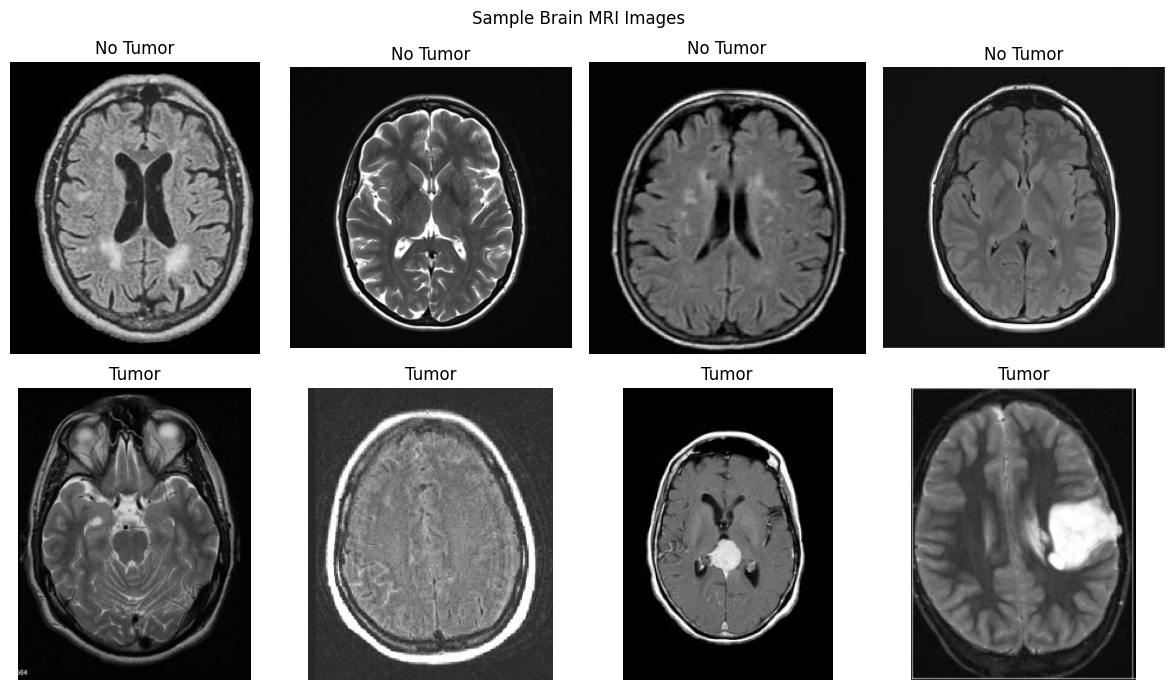

In [4]:
# Visualize representative images
sample_parts = []

for label in [0, 1]:
    part = df[df["label"] == label]
    sample_parts.append(
        part.sample(min(4, len(part)), random_state=SEED)
    )

sample_df = pd.concat(sample_parts).reset_index(drop=True)

plt.figure(figsize=(12, 7))

for i, row in sample_df.iterrows():
    img = plt.imread(row["filepath"])
    ax = plt.subplot(2, 4, i + 1)
    ax.imshow(img, cmap="gray")
    ax.set_title(row["class_name"])
    ax.axis("off")

plt.suptitle("Sample Brain MRI Images")
plt.tight_layout()
plt.show()



## 5. Preprocessing and Train / Validation / Test Split

- Input size: **224 × 224 × 3**
- Pixel values are normalized to **0–1** for the common dataset pipeline.
- Stratified split:
  - 70% training
  - 15% validation
  - 15% testing
- Augmentation is applied **only during training**.
- The test set remains untouched so that both models are evaluated fairly.


In [5]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nClass distribution:")
print("Training:")
print(train_df["class_name"].value_counts())
print("\nValidation:")
print(val_df["class_name"].value_counts())
print("\nTesting:")
print(test_df["class_name"].value_counts())


Train: 354
Validation: 76
Test: 76

Class distribution:
Training:
class_name
Tumor       217
No Tumor    137
Name: count, dtype: int64

Validation:
class_name
Tumor       47
No Tumor    29
Name: count, dtype: int64

Testing:
class_name
Tumor       46
No Tumor    30
Name: count, dtype: int64


In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, tf.cast(label, tf.float32)

def make_dataset(frame, training=False):
    paths = frame["filepath"].values
    labels = frame["label"].values.astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(
            buffer_size=len(frame),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

augmentation = keras.Sequential([
    layers.RandomRotation(0.15),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomZoom(0.10)
], name="data_augmentation")

print("Preprocessing and datasets created successfully.")


Preprocessing and datasets created successfully.



## 6. Model 1 — Custom CNN From Scratch

### Architecture
**Input → Augmentation → Conv2D(32) → MaxPooling → Conv2D(64) → MaxPooling → Conv2D(128) → MaxPooling → Global Average Pooling → Dense(128) → Dropout → Sigmoid**

The convolutional filters are randomly initialized and learned entirely from the MRI training data. No pretrained convolutional model is used.


In [7]:

def build_custom_cnn():
    inputs = keras.Input(shape=(*IMG_SIZE, 3))

    x = augmentation(inputs)

    x = layers.Conv2D(
        32, 3, padding="same", activation="relu",
        name="scratch_conv1"
    )(x)
    x = layers.MaxPooling2D(name="scratch_pool1")(x)

    x = layers.Conv2D(
        64, 3, padding="same", activation="relu",
        name="scratch_conv2"
    )(x)
    x = layers.MaxPooling2D(name="scratch_pool2")(x)

    x = layers.Conv2D(
        128, 3, padding="same", activation="relu",
        name="scratch_conv3"
    )(x)
    x = layers.MaxPooling2D(name="scratch_pool3")(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.40)(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="output"
    )(x)

    return keras.Model(
        inputs,
        outputs,
        name="CNN_From_Scratch"
    )

scratch_model = build_custom_cnn()

scratch_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

scratch_model.summary()

print("Total parameters:",
      f"{scratch_model.count_params():,}")

print("Trainable parameters:",
      f"{sum(np.prod(v.shape) for v in scratch_model.trainable_weights):,}")


Model: "CNN_From_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scratch_conv1 (Conv2D)          │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scratch_pool1 (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scratch_conv2 (Conv2D)          │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scratch_pool2 (MaxPooling2D)    │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scratch_conv3 (Conv2D)          │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scratch_pool3 (MaxPooling2D)    │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

Total parameters: 109,889
Trainable parameters: 109,889


In [8]:
def make_callbacks():
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=2,
            min_lr=1e-7
        )
    ]

EPOCHS_SCRATCH = 15

start_time = time.perf_counter()

history_scratch = scratch_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_SCRATCH,
    callbacks=make_callbacks(),
    verbose=1
)

scratch_training_time = time.perf_counter() - start_time

print(f"\nCNN training time: {scratch_training_time:.2f} seconds")
print(f"CNN training time: {scratch_training_time/60:.2f} minutes")


Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5339 - loss: 0.6840 - precision: 0.5890 - recall: 0.7926 - val_accuracy: 0.6184 - val_loss: 0.6698 - val_precision: 0.6184 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.6130 - loss: 0.6594 - precision: 0.6130 - recall: 1.0000 - val_accuracy: 0.6184 - val_loss: 0.6491 - val_precision: 0.6184 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.6130 - loss: 0.6527 - precision: 0.6130 - recall: 1.0000 - val_accuracy: 0.6184 - val_loss: 0.6439 - val_precision: 0.6184 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6130 - loss: 0.6385 - precision: 0.6130 - recall: 1.0000 - val_accuracy: 0.6184 - val_loss: 0.6427 - val_precision: 0.6184 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accu

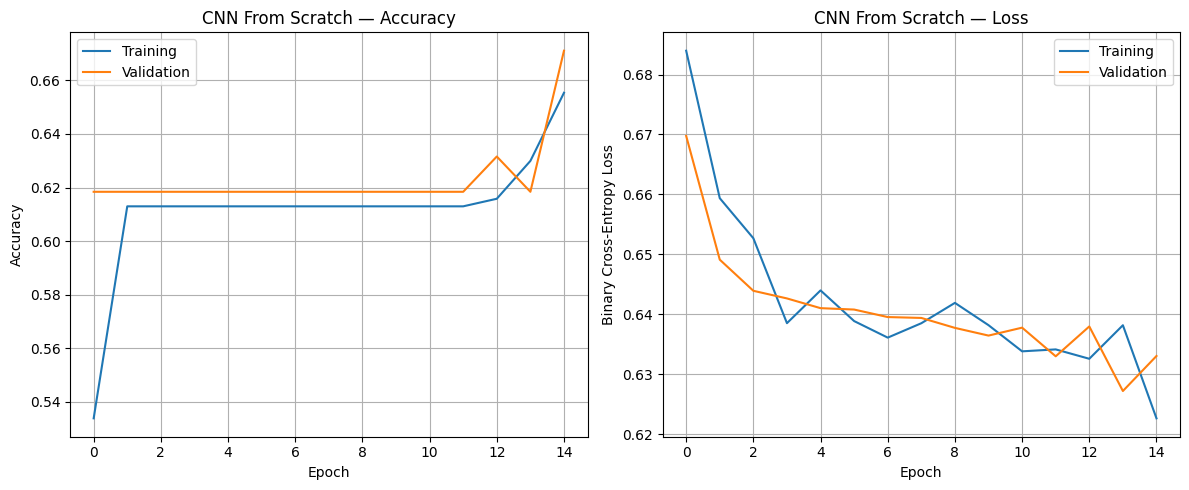

In [9]:

def plot_training_history(history, title):
    h = history.history

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(h["accuracy"], label="Training")
    plt.plot(h["val_accuracy"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " — Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(h["loss"], label="Training")
    plt.plot(h["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Binary Cross-Entropy Loss")
    plt.title(title + " — Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(
    history_scratch,
    "CNN From Scratch"
)



## 7. Model 2 — VGG-19 Transfer Learning

### Why VGG-19?
The reference research paper evaluated several pretrained architectures and reported VGG-19 as its best-performing model. Therefore VGG-19 is selected as the transfer-learning model for this practical.

### Strategy
1. Load ImageNet-pretrained VGG-19 without the original classifier.
2. Freeze the convolutional base.
3. Train a new binary classification head.
4. Unfreeze the final convolutional layers.
5. Fine-tune them using a smaller learning rate.


In [10]:
base_model = VGG19(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3))

x = augmentation(inputs)

# Dataset pipeline outputs 0-1, while VGG19 preprocessing
# expects the original 0-255 RGB range.
x = layers.Lambda(
    lambda z: preprocess_input(z * 255.0),
    name="vgg19_preprocess"
)(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.40)(x)

outputs = layers.Dense(
    1,
    activation="sigmoid",
    name="output"
)(x)

vgg19_model = keras.Model(
    inputs,
    outputs,
    name="VGG19_Transfer_Learning"
)

vgg19_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

total_params = vgg19_model.count_params()
trainable_before = sum(
    np.prod(v.shape)
    for v in vgg19_model.trainable_weights
)

print(f"Total VGG-19 parameters: {total_params:,}")
print(f"Trainable parameters before fine-tuning: {trainable_before:,}")

vgg19_model.summary()


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Total VGG-19 parameters: 20,090,177
Trainable parameters before fine-tuning: 65,793


Model: "VGG19_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19_preprocess (Lambda)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,090,177 (76.64 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [11]:
EPOCHS_HEAD = 8

start_time = time.perf_counter()

history_vgg_head = vgg19_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=make_callbacks(),
    verbose=1
)

head_training_time = time.perf_counter() - start_time

print(f"Head training time: {head_training_time:.2f} seconds")


Epoch 1/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 206s 9s/step - accuracy: 0.5452 - loss: 1.6107 - precision: 0.6400 - recall: 0.5899 - val_accuracy: 0.5921 - val_loss: 0.7990 - val_precision: 0.6250 - val_recall: 0.8511 - learning_rate: 1.0000e-04
Epoch 2/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 273s 9s/step - accuracy: 0.6497 - loss: 1.0235 - precision: 0.6996 - recall: 0.7512 - val_accuracy: 0.6316 - val_loss: 0.7095 - val_precision: 0.8065 - val_recall: 0.5319 - learning_rate: 1.0000e-04
Epoch 3/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 209s 9s/step - accuracy: 0.6808 - loss: 0.9875 - precision: 0.7321 - recall: 0.7558 - val_accuracy: 0.6974 - val_loss: 0.5958 - val_precision: 0.7609 - val_recall: 0.7447 - learning_rate: 1.0000e-04
Epoch 4/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 262s 9s/step - accuracy: 0.6864 - loss: 0.9756 - precision: 0.7409 - recall: 0.7512 - val_accuracy: 0.7105 - val_loss: 0.6415 - val_precision: 0.8571 - val_recall: 0.6383 - learning_rate: 1.0000e-04
Epoch 5/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 258s 9s/step - accu

In [12]:
base_model.trainable = True

# Freeze all but the final 8 VGG-19 layers
for layer in base_model.layers[:-8]:
    layer.trainable = False

vgg19_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

print("Trainable VGG-19 convolutional layers:")
for layer in base_model.layers:
    if layer.trainable:
        print(" -", layer.name)

trainable_after = sum(
    np.prod(v.shape)
    for v in vgg19_model.trainable_weights
)

print(f"\nTrainable parameters after fine-tuning: {trainable_after:,}")

EPOCHS_FINE = 7

start_time = time.perf_counter()

history_vgg_fine = vgg19_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=make_callbacks(),
    verbose=1
)

fine_training_time = time.perf_counter() - start_time
vgg_training_time = head_training_time + fine_training_time

print(f"Fine-tuning time: {fine_training_time:.2f} seconds")
print(f"Total VGG-19 training time: {vgg_training_time:.2f} seconds")
print(f"Total VGG-19 training time: {vgg_training_time/60:.2f} minutes")


Trainable VGG-19 convolutional layers:
 - block4_conv3
 - block4_conv4
 - block4_pool
 - block5_conv1
 - block5_conv2
 - block5_conv3
 - block5_conv4
 - block5_pool

Trainable parameters after fine-tuning: 14,224,641
Epoch 1/7
23/23 ━━━━━━━━━━━━━━━━━━━━ 316s 14s/step - accuracy: 0.6893 - loss: 0.8354 - precision: 0.7378 - recall: 0.7650 - val_accuracy: 0.7763 - val_loss: 0.4568 - val_precision: 0.8409 - val_recall: 0.7872 - learning_rate: 1.0000e-05
Epoch 2/7
23/23 ━━━━━━━━━━━━━━━━━━━━ 323s 14s/step - accuracy: 0.7712 - loss: 0.5197 - precision: 0.8009 - recall: 0.8341 - val_accuracy: 0.7632 - val_loss: 0.4896 - val_precision: 0.8919 - val_recall: 0.7021 - learning_rate: 1.0000e-05
Epoch 3/7
23/23 ━━━━━━━━━━━━━━━━━━━━ 321s 14s/step - accuracy: 0.8079 - loss: 0.4323 - precision: 0.8225 - recall: 0.8756 - val_accuracy: 0.6974 - val_loss: 0.4959 - val_precision: 0.8750 - val_recall: 0.5957 - learning_rate: 1.0000e-05
Epoch 4/7
23/23 ━━━━━━━━━━━━━━━━━━━━ 321s 14s/step - accuracy: 0.8757 - 

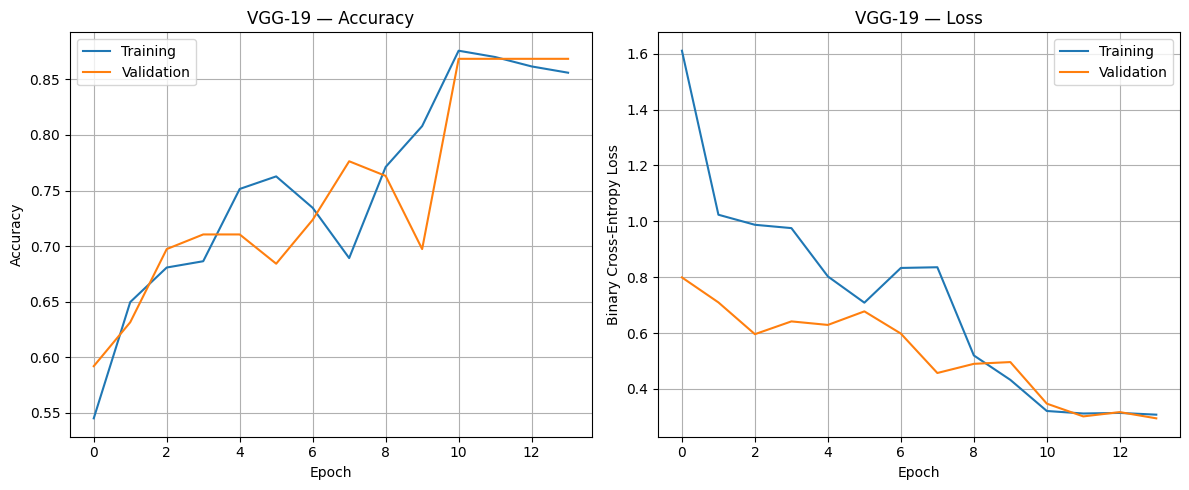

In [13]:

# Combine head-training and fine-tuning histories
def combine_histories(h1, h2):
    combined = {}
    keys = set(h1.history.keys()).union(h2.history.keys())

    for key in keys:
        combined[key] = (
            h1.history.get(key, []) +
            h2.history.get(key, [])
        )

    return combined

vgg_history = combine_histories(
    history_vgg_head,
    history_vgg_fine
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(vgg_history["accuracy"], label="Training")
plt.plot(vgg_history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("VGG-19 — Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(vgg_history["loss"], label="Training")
plt.plot(vgg_history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("VGG-19 — Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



## 8. Feature Extraction / Feature Maps

Feature maps demonstrate what convolutional layers learn internally. Early layers generally respond to low-level patterns such as edges and textures, while deeper layers learn more task-relevant visual representations.


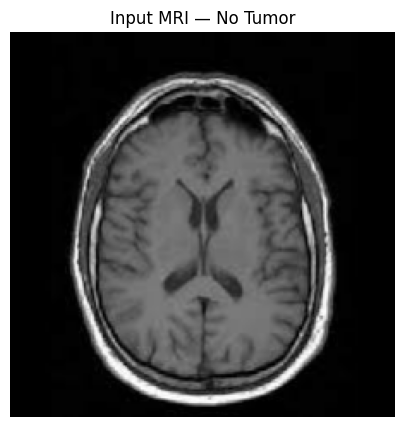

In [14]:

# Select one test image
sample_path = test_df.iloc[0]["filepath"]
sample_label = int(test_df.iloc[0]["label"])

raw_img = tf.io.read_file(sample_path)
raw_img = tf.image.decode_image(
    raw_img,
    channels=3,
    expand_animations=False
)
raw_img = tf.image.resize(raw_img, IMG_SIZE)
raw_img = tf.cast(raw_img, tf.float32)

plt.figure(figsize=(5, 5))
plt.imshow(raw_img.numpy().astype(np.uint8))
plt.title(
    "Input MRI — " +
    ("Tumor" if sample_label == 1 else "No Tumor")
)
plt.axis("off")
plt.show()


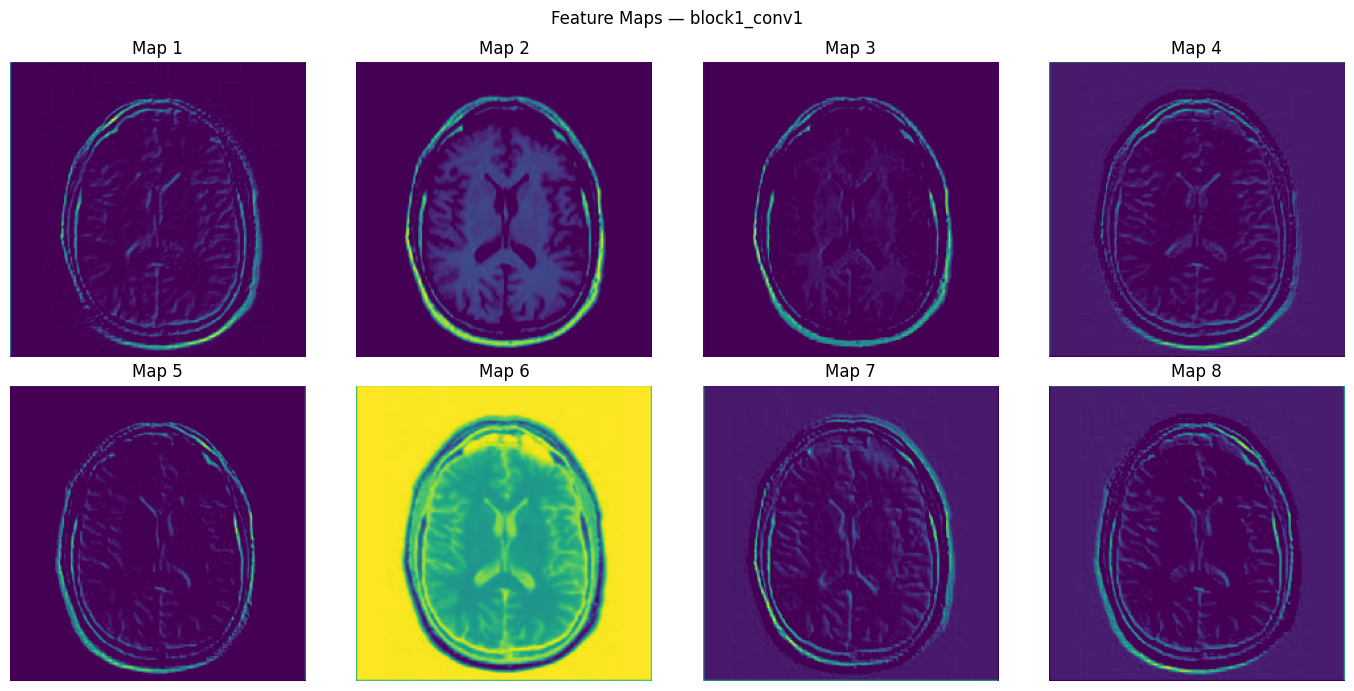

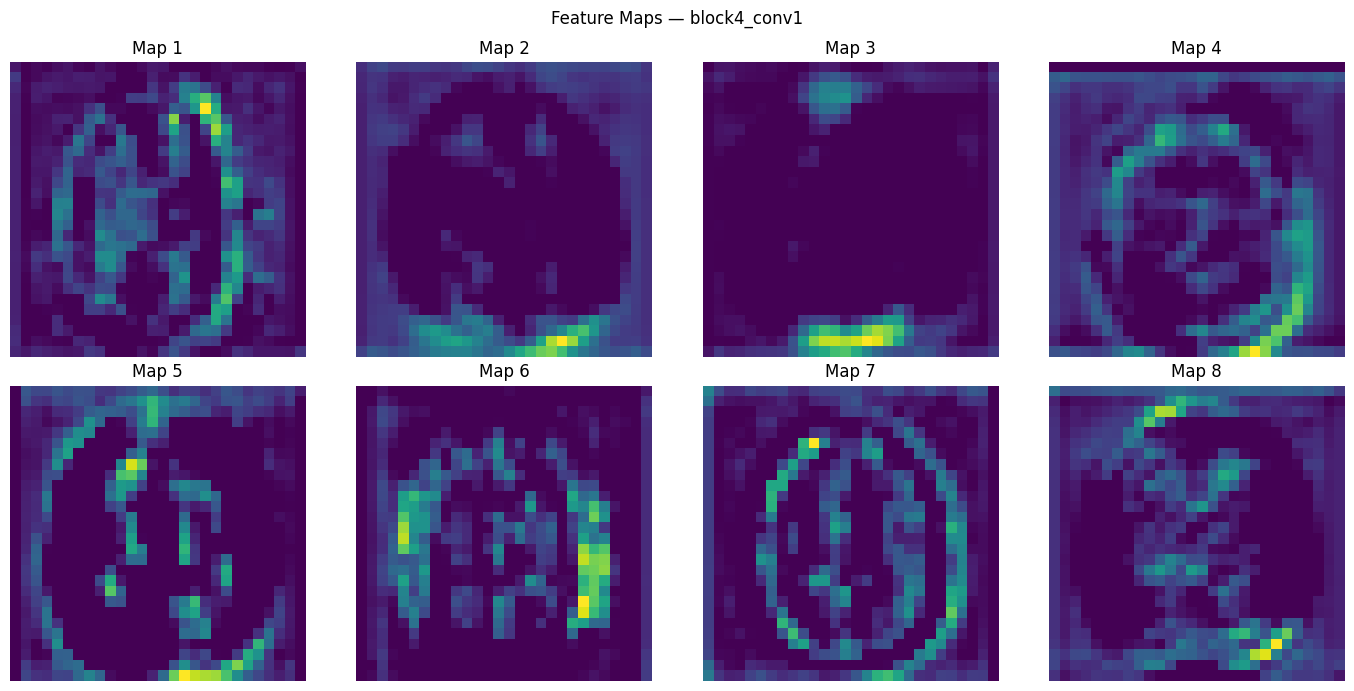

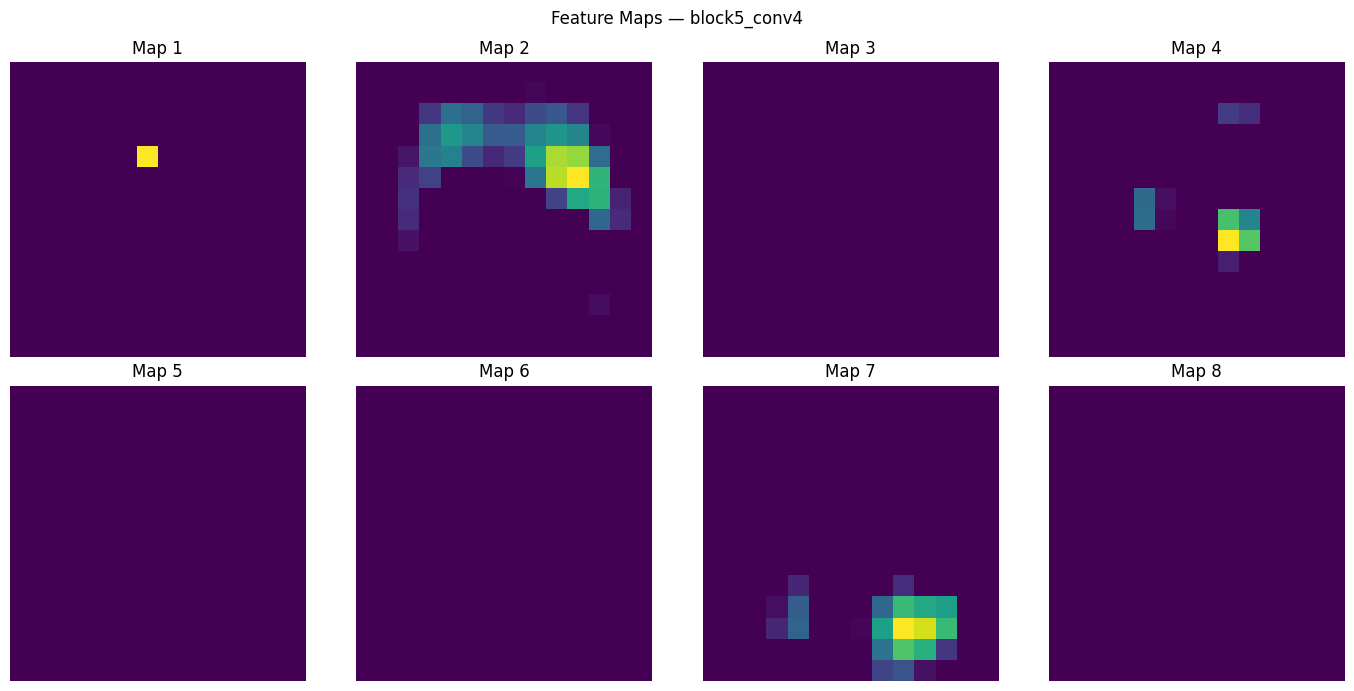

In [15]:

# Feature maps from selected VGG-19 convolutional layers
conv_layers = [
    layer for layer in base_model.layers
    if isinstance(layer, layers.Conv2D)
]

selected_layers = [
    conv_layers[0],
    conv_layers[len(conv_layers) // 2],
    conv_layers[-1]
]

feature_model = keras.Model(
    inputs=base_model.input,
    outputs=[layer.output for layer in selected_layers]
)

processed = preprocess_input(
    tf.expand_dims(raw_img, axis=0)
)

feature_maps = feature_model(
    processed,
    training=False
)

for layer, fmap in zip(selected_layers, feature_maps):
    fmap = fmap[0].numpy()
    n_channels = min(8, fmap.shape[-1])

    plt.figure(figsize=(14, 7))

    for i in range(n_channels):
        ax = plt.subplot(2, 4, i + 1)
        ax.imshow(fmap[:, :, i], cmap="viridis")
        ax.set_title(f"Map {i + 1}")
        ax.axis("off")

    plt.suptitle(
        f"Feature Maps — {layer.name}"
    )
    plt.tight_layout()
    plt.show()



## 9. Model Evaluation

The final evaluation uses the **same untouched test set** for both models.

Metrics:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix


In [16]:

def evaluate_model(model, dataset, true_labels):
    probabilities = model.predict(
        dataset,
        verbose=0
    ).ravel()

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    y_true = np.asarray(true_labels).astype(int)

    metrics = {
        "Accuracy": accuracy_score(
            y_true, predictions
        ),
        "Precision": precision_score(
            y_true, predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true, predictions,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_true, predictions,
            zero_division=0
        )
    }

    return metrics, predictions, probabilities


scratch_metrics, scratch_pred, scratch_prob = evaluate_model(
    scratch_model,
    test_ds,
    test_df["label"].values
)

vgg_metrics, vgg_pred, vgg_prob = evaluate_model(
    vgg19_model,
    test_ds,
    test_df["label"].values
)

comparison = pd.DataFrame(
    [scratch_metrics, vgg_metrics],
    index=[
        "CNN From Scratch",
        "VGG-19 Transfer Learning"
    ]
)

display(
    comparison.style.format("{:.4f}")
)


,Accuracy,Precision,Recall,F1-score
CNN From Scratch,0.6184,0.6133,1.0000,0.7603
VGG-19 Transfer Learning,0.8947,0.9130,0.9130,0.9130


In [17]:

# Classification reports
print("=" * 60)
print("CNN FROM SCRATCH")
print("=" * 60)

print(
    classification_report(
        test_df["label"],
        scratch_pred,
        target_names=["No Tumor", "Tumor"],
        digits=4
    )
)

print("=" * 60)
print("VGG-19 TRANSFER LEARNING")
print("=" * 60)

print(
    classification_report(
        test_df["label"],
        vgg_pred,
        target_names=["No Tumor", "Tumor"],
        digits=4
    )
)


CNN FROM SCRATCH
              precision    recall  f1-score   support

    No Tumor     1.0000    0.0333    0.0645        30
       Tumor     0.6133    1.0000    0.7603        46

    accuracy                         0.6184        76
   macro avg     0.8067    0.5167    0.4124        76
weighted avg     0.7660    0.6184    0.4857        76

VGG-19 TRANSFER LEARNING
              precision    recall  f1-score   support

    No Tumor     0.8667    0.8667    0.8667        30
       Tumor     0.9130    0.9130    0.9130        46

    accuracy                         0.8947        76
   macro avg     0.8899    0.8899    0.8899        76
weighted avg     0.8947    0.8947    0.8947        76



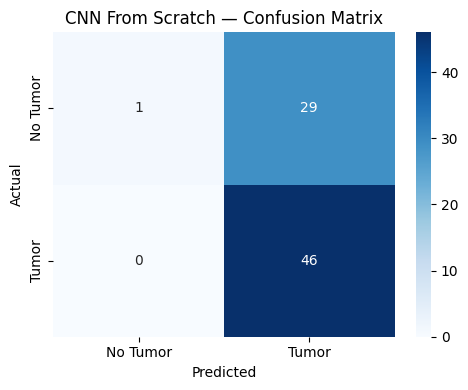

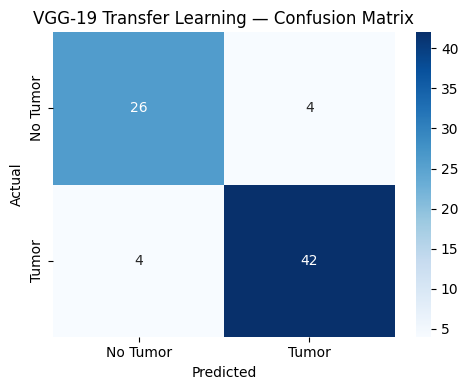

In [18]:

def plot_confusion_matrix(y_true, predictions, title):
    cm = confusion_matrix(
        y_true,
        predictions
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Tumor", "Tumor"],
        yticklabels=["No Tumor", "Tumor"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(
    test_df["label"],
    scratch_pred,
    "CNN From Scratch — Confusion Matrix"
)

plot_confusion_matrix(
    test_df["label"],
    vgg_pred,
    "VGG-19 Transfer Learning — Confusion Matrix"
)



## 10. Training Time and Model Complexity Comparison

Training time is measured directly during execution. Parameter counts are obtained from the actual Keras models. **Do not manually enter or invent these values.**


In [19]:
scratch_total = scratch_model.count_params()
scratch_trainable = sum(
    np.prod(v.shape)
    for v in scratch_model.trainable_weights
)

vgg_total = vgg19_model.count_params()
vgg_trainable = sum(
    np.prod(v.shape)
    for v in vgg19_model.trainable_weights
)

final_comparison = pd.DataFrame({
    "Accuracy": [
        scratch_metrics["Accuracy"],
        vgg_metrics["Accuracy"]
    ],
    "Precision": [
        scratch_metrics["Precision"],
        vgg_metrics["Precision"]
    ],
    "Recall": [
        scratch_metrics["Recall"],
        vgg_metrics["Recall"]
    ],
    "F1-score": [
        scratch_metrics["F1-score"],
        vgg_metrics["F1-score"]
    ],
    "Training Time (sec)": [
        scratch_training_time,
        vgg_training_time
    ],
    "Total Parameters": [
        scratch_total,
        vgg_total
    ],
    "Trainable Parameters": [
        scratch_trainable,
        vgg_trainable
    ]
}, index=[
    "CNN From Scratch",
    "VGG-19 Transfer Learning"
])

display(final_comparison)

print("\nModel complexity:")
print(
    f"CNN From Scratch: {scratch_total:,} total parameters"
)
print(
    f"VGG-19: {vgg_total:,} total parameters"
)


,Accuracy,Precision,Recall,F1-score,Training Time (sec),Total Parameters,Trainable Parameters
CNN From Scratch,0.618421,0.613333,1.000000,0.760331,528.401189,109889,109889
VGG-19 Transfer Learning,0.894737,0.913043,0.913043,0.913043,3979.072596,20090177,14224641



Model complexity:
CNN From Scratch: 109,889 total parameters
VGG-19: 20,090,177 total parameters


In [21]:
improvement = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "CNN From Scratch": [
        scratch_metrics["Accuracy"],
        scratch_metrics["Precision"],
        scratch_metrics["Recall"],
        scratch_metrics["F1-score"]
    ],
    "VGG-19 Transfer Learning": [
        vgg_metrics["Accuracy"],
        vgg_metrics["Precision"],
        vgg_metrics["Recall"],
        vgg_metrics["F1-score"]
    ]
})

improvement["VGG19 - CNN"] = (
    improvement["VGG-19 Transfer Learning"]
    - improvement["CNN From Scratch"]
)

display(
    improvement.style.format({
        "CNN From Scratch": "{:.4f}",
        "VGG-19 Transfer Learning": "{:.4f}",
        "VGG19 - CNN": "{:+.4f}"
    })
)


,Metric,CNN From Scratch,VGG-19 Transfer Learning,VGG19 - CNN
0,Accuracy,0.6184,0.8947,+0.2763
1,Precision,0.6133,0.9130,+0.2997
2,Recall,1.0000,0.9130,-0.0870
3,F1-score,0.7603,0.9130,+0.1527



## 11. Comparison With the Research Paper

The following values are taken from the reference paper and are shown separately from the student's experimental results.

| Model | Accuracy | Recall | Precision | F1-score |
|---|---:|---:|---:|---:|
| VGG-19 | 99.48% | 98.76% | 100.00% | 99.17% |
| VGG-16 | 99.00% | 98.18% | 100.00% | 99.08% |
| ResNet50 | 97.92% | — | — | — |
| InceptionV3 | 81.25% | — | — | — |

The student's VGG-19 result should not be expected to exactly match the paper because the dataset split, augmentation, training budget, preprocessing, fine-tuning and hardware can differ.


In [22]:

paper_vgg19 = {
    "Accuracy": 0.9948,
    "Precision": 1.0000,
    "Recall": 0.9876,
    "F1-score": 0.9917
}

paper_vs_student = pd.DataFrame({
    "Research Paper VGG-19": paper_vgg19,
    "This Notebook VGG-19": vgg_metrics
}).T

print("Research Paper VGG-19 vs Student VGG-19")
display(
    paper_vs_student.style.format("{:.4f}")
)

difference = {
    metric:
        vgg_metrics[metric] - paper_vgg19[metric]
    for metric in paper_vgg19
}

print("\nStudent result minus paper result:")
for metric, value in difference.items():
    print(f"{metric}: {value:+.4f}")


Research Paper VGG-19 vs Student VGG-19


,Accuracy,Precision,Recall,F1-score
Research Paper VGG-19,0.9948,1.0000,0.9876,0.9917
This Notebook VGG-19,0.8947,0.9130,0.9130,0.9130



Student result minus paper result:
Accuracy: -0.1001
Precision: -0.0870
Recall: -0.0746
F1-score: -0.0787



## 12. Automatic Result-Based Conclusion

The conclusion below is generated from the **actual test results** rather than assuming which model wins.


In [23]:
f1_scratch = scratch_metrics["F1-score"]
f1_vgg = vgg_metrics["F1-score"]

acc_scratch = scratch_metrics["Accuracy"]
acc_vgg = vgg_metrics["Accuracy"]

if f1_vgg > f1_scratch:
    winner = "VGG-19 Transfer Learning"
    reason = (
        "VGG-19 achieved the higher test F1-score. "
        "The pretrained ImageNet representation and fine-tuning "
        "provided stronger overall classification performance "
        "on this test split."
    )
elif f1_scratch > f1_vgg:
    winner = "CNN From Scratch"
    reason = (
        "The custom CNN achieved the higher test F1-score "
        "on this test split. This indicates that the smaller "
        "task-specific architecture was sufficient for this dataset."
    )
else:
    winner = "Both models are tied on F1-score"
    reason = (
        "Both models achieved the same test F1-score, so "
        "model complexity and training time become important "
        "factors in selecting the preferred approach."
    )

print("FINAL RESULT")
print("-" * 60)
print(f"Best model by F1-score: {winner}")
print(f"CNN Accuracy: {acc_scratch:.4f}")
print(f"VGG-19 Accuracy: {acc_vgg:.4f}")
print(f"CNN F1-score: {f1_scratch:.4f}")
print(f"VGG-19 F1-score: {f1_vgg:.4f}")
print()
print("Conclusion:")
print(reason)

print("\nImportant:")
print(
    "A higher score on this single test split does not prove "
    "clinical superiority. The experiment is an academic "
    "image-classification comparison."
)


FINAL RESULT
------------------------------------------------------------
Best model by F1-score: VGG-19 Transfer Learning
CNN Accuracy: 0.6184
VGG-19 Accuracy: 0.8947
CNN F1-score: 0.7603
VGG-19 F1-score: 0.9130

Conclusion:
VGG-19 achieved the higher test F1-score. The pretrained ImageNet representation and fine-tuning provided stronger overall classification performance on this test split.

Important:
A higher score on this single test split does not prove clinical superiority. The experiment is an academic image-classification comparison.



## 13. Advantages and Limitations

### CNN From Scratch — Advantages
- Fewer parameters
- Lower model complexity
- Easier to understand and implement
- Can be faster and lighter for deployment
- Learns features specifically from the target dataset

### CNN From Scratch — Limitations
- Needs to learn all visual features from a relatively small dataset
- More vulnerable to overfitting
- May perform worse when training data is limited

### VGG-19 Transfer Learning — Advantages
- Starts with useful pretrained visual features
- Often effective for small datasets
- Fine-tuning adapts pretrained features to the target task
- Strong baseline for image classification

### VGG-19 Transfer Learning — Limitations
- Much larger number of parameters
- Higher memory and computational requirements
- Longer training/inference cost
- ImageNet features come from natural images rather than MRI scans
- Results may vary with the dataset split and preprocessing



## 14. Conclusion

This practical implemented binary brain MRI image classification using two approaches: a custom CNN trained from scratch and VGG-19 transfer learning.

The custom CNN demonstrates how convolutional features can be learned directly from the target MRI dataset. VGG-19 demonstrates transfer learning by starting from ImageNet-pretrained features and then fine-tuning selected convolutional layers.

The final comparison uses Accuracy, Precision, Recall, F1-score, training time and model complexity. The confusion matrices and training curves provide additional evidence for comparing the two approaches.

The reference paper provides a research baseline, while this notebook provides an independent student experiment. Differences between the published and student results are expected because the experimental setup is not identical.

**The preferred model should be selected from the actual test results while also considering accuracy, F1-score, computational cost and model complexity.**
